In [1]:
from cytograph import Algorithm, creates, requires, div0
from cytograph.visualization.scatter import scatterc, scattern
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np
from typing import List
import shoji
import cytograph as cg
import cytograph.visualization as cgplot
import collections
from typing import List, Optional
import matplotlib.patheffects as PathEffects
import fastcluster
import igraph
import leidenalg as la
import scipy.cluster.hierarchy as hc
from hmmlearn import hmm
from openTSNE import TSNE
from pynndescent import NNDescent
from scipy.spatial.distance import pdist
from sklearn.decomposition import PCA
from tqdm import trange
import warnings
import pandas as pd
warnings.filterwarnings('ignore')
from cytograph.visualization import Colorizer
from matplotlib.lines import Line2D
import scipy as sci
import loompy
import scanpy as sc
from scipy.stats import ks_2samp, mannwhitneyu, ttest_ind

In [7]:
# Load the sample data into your local Shoji database
Astrocyte = sc.read_h5ad('/proj/cytograph/jesper/GBM_revision/h5ad/bulk_samples_Astrocytes_smartseq_2025.h5ad')

In [8]:
Astrocyte.obs.index = [x for x in Astrocyte.obs.obs_names]

In [9]:
Astrocyte

AnnData object with n_obs × n_vars = 37 × 63757
    obs: 'Barcode', 'BarcodeIdx', 'Celltype', 'Condition', 'Hypoxia', 'ID', 'Pool', 'Sample', 'Sample_Condition', 'Sample_Time_Condition', 'Time', 'Time_Condition', 'TotalMTCounts', 'TotalReadGenes', 'TotalReads', 'TotalUMIGenes', 'TotalUMIs', 'obs_names'
    var: 'Accession', 'Chromosome'
    layers: 'Exon'

In [10]:
Astrocyte.obs

,Barcode,BarcodeIdx,Celltype,Condition,Hypoxia,ID,Pool,Sample,Sample_Condition,Sample_Time_Condition,Time,Time_Condition,TotalMTCounts,TotalReadGenes,TotalReads,TotalUMIGenes,TotalUMIs,obs_names
B10,-,13,Astrocyte,-P+H,Yes,B10,20250915,SVG_2,SVG_2_-P+H,SVG_2t3-P+H,t3,t3-P+H,597761,19869,20163688,19869,20163688,B10
B11,-,14,Astrocyte,+P+H,Yes,B11,20250915,SVG_2,SVG_2_+P+H,SVG_2t3+P+H,t3,t3+P+H,474191,19097,19143782,19097,19143782,B11
B12,-,15,Astrocyte,-P-H,No,B12,20250915,SVG_2,SVG_2_-P-H,SVG_2t3-P-H,t3,t3-P-H,700071,20035,19796107,20035,19796107,B12
B05,-,19,Astrocyte,-P-H,No,B05,20250915,SVG_2,SVG_2_-P-H,SVG_20h-P-H,0h,0h-P-H,722705,19969,19549530,19969,19549530,B05
B06,-,20,Astrocyte,-P+H,Yes,B06,20250915,SVG_2,SVG_2_-P+H,SVG_2t1-P+H,t1,t1-P+H,1179630,20354,19322022,20354,19322022,B06
B07,-,21,Astrocyte,+P+H,Yes,B07,20250915,SVG_2,SVG_2_+P+H,SVG_2t1+P+H,t1,t1+P+H,673520,21505,19200522,21505,19200522,B07
B08,-,22,Astrocyte,-P-H,No,B08,20250915,SVG_2,SVG_2_-P-H,SVG_2t1-P-H,t1,t1-P-H,954012,20301,18893603,20301,18893603,B08
B09,-,23,Astrocyte,+P-H,No,B09,20250915,SVG_2,SVG_2_+P-H,SVG_2t3+P-H,t3,t3+P-H,1010212,20858,18676299,20858,18676299,B09
C01,-,24,Astrocyte,+P-H,No,C01,20250915,SVG_2,SVG_2_+P-H,SVG_2t6+P-H,t6,t6+P-H,696733,20339,16411686,20339,16411686,C01
C10,-,25,Astrocyte,-P+H,Yes,C10,20250915,SVG_1,SVG_1_-P+H,SVG_1t3-P+H,t3,t3-P+H,1191271,21422,17215507,21422,17215507,C10


In [11]:
MES1 = np.array(["CHI3L1","ANXA2","ANXA1","CD44","VIM","MT2A","C1S","NAMPT","EFEMP1","C1R","SOD2","IFITM3","TIMP1","SPP1","A2M","S100A11","MT1X","S100A10","FN1","LGALS1","S100A16","CLIC1","MGST1","RCAN1","TAGLN2","NPC2","SERPING1","TCIM","EMP1","APOE","CTSB","C3","LGALS3","MT1E","EMP3","SERPINA3","ACTN1","PRDX6","IGFBP7","SERPINE1","PLP2","MGP","CLIC4","GFPT2","GSN","NNMT","TUBA1C","GJA1","TNFRSF1A","WWTR1"])
MES2 = np.array(["HILPDA","ADM","DDIT3","NDRG1","HERPUD1","DNAJB9","TRIB3","ENO2","AKAP12","SQSTM1","MT1X","ATF3","NAMPT","NRN1","SLC2A1","BNIP3","LGALS3","INSIG2","IGFBP3","PPP1R15A","VIM","PLOD2","GBE1","SLC2A3","FTL","WARS1","ERO1A","XPOT","HSPA5","GDF15","ANXA2","EPAS1","LDHA","P4HA1","SERTAD1","PFKP","PGK1","EGLN3","SLC6A6","CA9","BNIP3L","RPL21","TRAM1","UFM1","ASNS","GOLT1B","ANGPTL4","SLC39A14","CDKN1A","HSPA9"])
gene_list = np.concatenate((MES1, MES2))
_, i = np.unique(gene_list, return_index=True)
gene_list = gene_list[np.sort(i)]

In [12]:
df = Astrocyte.to_df(layer=None)
df_all = df.sum(axis=1)
MES_df = df[gene_list]
df_mes = MES_df.sum(axis=1)
zero = Astrocyte[Astrocyte.obs["Time"] == "0h"]
zero_all = df_all[zero.obs.index]
zero_mes = df_mes[zero.obs.index]
one = Astrocyte[Astrocyte.obs["Time"] == "t1"]
one_all = df_all[one.obs.index]
one_mes = df_mes[one.obs.index]
three = Astrocyte[Astrocyte.obs["Time"] == "t3"]
three_all = df_all[three.obs.index]
three_mes = df_mes[three.obs.index]
six = Astrocyte[Astrocyte.obs["Time"] == "t6"]
six_all = df_all[six.obs.index]
six_mes = df_mes[six.obs.index]
MES_zero = zero_mes/zero_all
MES_one = one_mes/one_all
MES_three = three_mes/three_all
MES_six = six_mes/six_all
merged = pd.concat([MES_zero, MES_one, MES_three, MES_six], axis=1)
merged = merged.rename(columns={0: '0', 1: '24', 2:'72', 3: '144'})
rename = dict(Astrocyte.obs.Sample_Condition)
merged1 = merged.rename(index=rename)
merged1 = merged1.multiply(100)
rename = dict(Astrocyte.obs.Condition)
merg = merged.rename(index=rename)
merg = merg.mean(level=0)
merged1 = merged1.mean(level=0)
merged1 = merged1.reindex(["SVG_1_-P-H",'SVG_2_-P-H','SVG_3_-P-H',"SVG_1_+P-H","SVG_2_+P-H","SVG_3_+P-H","SVG_1_-P+H",'SVG_2_-P+H','SVG_3_-P+H',"SVG_1_+P+H",'SVG_2_+P+H','SVG_3_+P+H'])
merged1['0'] = dict(zip(merged1.index,np.concatenate(np.repeat([merged1[0:3]['0']], 4, axis=0))))
merged2 = merged1
merged1 = merged1.rename(index=dict(zip(merged1.index,["-P-H",'-P-H','-P-H',"+P-H","+P-H","+P-H","-P+H",'-P+H','-P+H',"+P+H",'+P+H','+P+H'])))
merg = merg.reindex(['-P-H', '+P-H','-P+H','+P+H'])
merg = merg.replace(np.nan, merg.iloc[0][0])
merg = merg.multiply(100)
merged1

,0,24,72,144
-P-H,2.717740,2.887754,2.786009,2.816845
-P-H,3.098499,2.931262,2.798626,NaN
-P-H,3.327716,3.051045,2.703750,2.809827
+P-H,2.717740,3.003360,2.895103,3.191637
+P-H,3.098499,NaN,3.043435,2.912175
+P-H,3.327716,3.141867,3.226490,2.775054
-P+H,2.717740,2.913179,2.725938,2.597127
-P+H,3.098499,3.295846,3.412694,2.690048
-P+H,3.327716,3.379380,3.363513,3.841841
+P+H,2.717740,3.886487,3.739584,2.891553


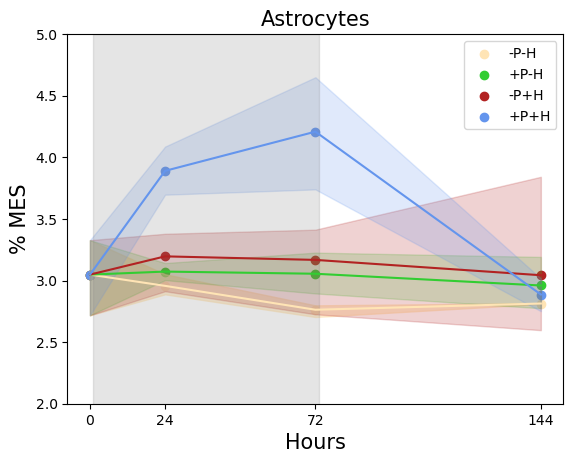

In [13]:
numb = merg.columns.astype(int)
plt.scatter(numb, merg.iloc[0],label=(merg.index[0]), color='moccasin')
plt.scatter(numb, merg.iloc[1],label=(merg.index[1]), color='limegreen')
plt.scatter(numb, merg.iloc[2],label=(merg.index[2]), color='firebrick')
plt.scatter(numb, merg.iloc[3],label=(merg.index[3]), color='cornflowerblue')
plt.plot(numb, merg.iloc[0], color='moccasin')
plt.fill_between(numb,np.min(merged1[0:3]),np.max(merged1[0:3]), color='moccasin', alpha=0.6)
plt.plot(numb, merg.iloc[1], color='limegreen')
plt.fill_between(numb,np.min(merged1[3:6]),np.max(merged1[3:6]), color='limegreen', alpha=0.2)
plt.plot(numb, merg.iloc[2], color='firebrick')
plt.fill_between(numb,np.min(merged1[6:9]),np.max(merged1[6:9]), color='firebrick', alpha=0.2)
plt.plot(numb, merg.iloc[3], color='cornflowerblue')
plt.fill_between(numb,np.min(merged1[9:12]),np.max(merged1[9:12]), color='cornflowerblue', alpha=0.2)
plt.ylim(2, 5)
plt.legend()
plt.xlabel('Hours', fontsize=15)
plt.ylabel('% MES', fontsize=15)
plt.title('Astrocytes', fontsize=15)
plt.xticks(numb)
threshold1 = 0.2
threshold2 = 71
tr = numb +1.1
plt.fill_between(tr, 5, where= (tr < 140) & (tr > 0), color='grey', alpha=0.2)

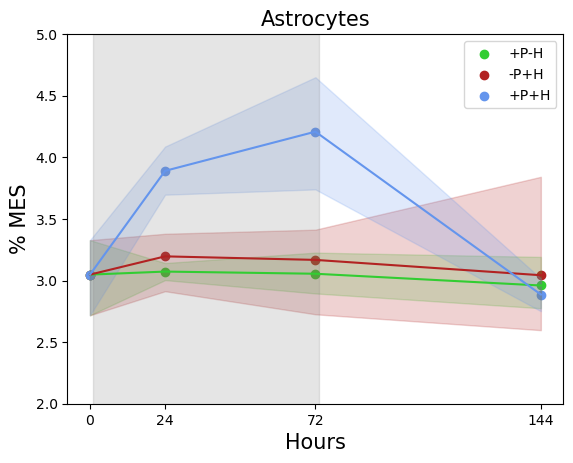

In [14]:
numb = merg.columns.astype(int)
#plt.scatter(numb, merg.iloc[0],label=(merg.index[0]), color='grey')
plt.scatter(numb, merg.iloc[1],label=(merg.index[1]), color='limegreen')
plt.scatter(numb, merg.iloc[2],label=(merg.index[2]), color='firebrick')
plt.scatter(numb, merg.iloc[3],label=(merg.index[3]), color='cornflowerblue')
plt.plot(numb, merg.iloc[1], color='limegreen')
plt.fill_between(numb,np.min(merged1[3:6]),np.max(merged1[3:6]), color='limegreen', alpha=0.2)
plt.plot(numb, merg.iloc[2], color='firebrick')
plt.fill_between(numb,np.min(merged1[6:9]),np.max(merged1[6:9]), color='firebrick', alpha=0.2)
plt.plot(numb, merg.iloc[3], color='cornflowerblue')
plt.fill_between(numb,np.min(merged1[9:12]),np.max(merged1[9:12]), color='cornflowerblue', alpha=0.2)
plt.ylim(2, 5)
plt.legend()
plt.xlabel('Hours', fontsize=15)
plt.ylabel('% MES', fontsize=15)
plt.title('Astrocytes', fontsize=15)
plt.xticks(numb)
threshold1 = 0.2
threshold2 = 71
tr = numb +1.1
plt.fill_between(tr, 5, where= (tr < 140) & (tr > 0), color='grey', alpha=0.2)

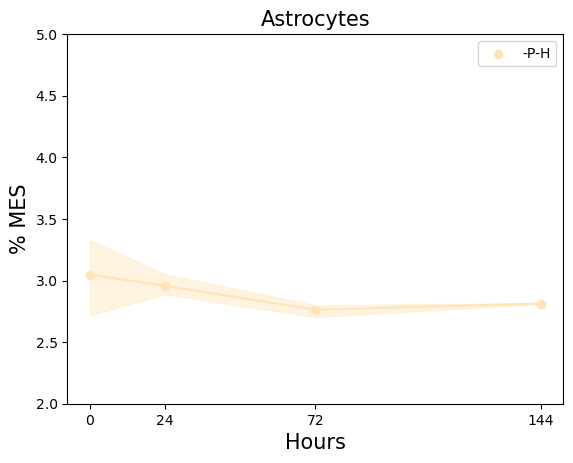

In [15]:
numb = merg.columns.astype(int)
plt.scatter(numb, merg.iloc[0],label=(merg.index[0]), color='moccasin')
plt.plot(numb, merg.iloc[0], color='moccasin')
plt.fill_between(numb,np.min(merged1[0:3]),np.max(merged1[0:3]), color='moccasin', alpha=0.4)
plt.ylim(2, 5)
plt.legend()
plt.xlabel('Hours', fontsize=15)
plt.ylabel('% MES', fontsize=15)
plt.title('Astrocytes', fontsize=15)
plt.xticks(numb)
threshold1 = 0.2
threshold2 = 71
tr = numb +3

In [26]:
#+p-h all timepoints vs start
x, p1 = mannwhitneyu(merged1[3:6]['0'], merged1[3:6]['24'].dropna(how='all'), alternative='less')
x, p2 = mannwhitneyu(merged1[3:6]['0'], merged1[3:6]['72'], alternative='less')
x, p3 = mannwhitneyu(merged1[3:6]['0'], merged1[3:6]['144'], alternative='less') 
#-p+h all timepoints vs start
x, p4 = mannwhitneyu(merged1[6:9]['0'], merged1[6:9]['24'], alternative='less')
x, p5 = mannwhitneyu(merged1[6:9]['0'], merged1[6:9]['72'], alternative='less')
x, p6 = mannwhitneyu(merged1[6:9]['0'], merged1[6:9]['144'], alternative='less') 
#+p+h all timepoints vs start
x, p7 = mannwhitneyu(merged1[9:12]['0'], merged1[9:12]['24'], alternative='less')
x, p8 = mannwhitneyu(merged1[9:12]['0'], merged1[9:12]['72'], alternative='less')
x, p9 = mannwhitneyu(merged1[9:12]['0'], merged1[9:12]['144'], alternative='less') 

In [27]:
comp = ['+p-H_24vs0h','+p-H_72vs0h','+p-H_144vs0h','-p+H_24vs0h','-p+H_72vs0h','-p+H_144vs0h','+p+H_24vs0h','+p+H_72vs0h','+p+H_144vs0h']
x = pd.Series([p1,p2,p3,p4,p5,p6,p7,p8,p9], index =comp)
x

+p-H_24vs0h     0.60
+p-H_72vs0h     0.65
+p-H_144vs0h    0.65
-p+H_24vs0h     0.35
-p+H_72vs0h     0.20
-p+H_144vs0h    0.80
+p+H_24vs0h     0.05
+p+H_72vs0h     0.05
+p+H_144vs0h    0.80
dtype: float64

In [28]:
x, p2 =  mannwhitneyu(merged1[3:6]['72'], merged1[3:6]['144'], alternative='greater')
x, p2 =  mannwhitneyu(merged1[6:9]['72'], merged1[6:9]['144'], alternative='greater')
x, p3 = mannwhitneyu(merged1[9:12]['72'], merged1[9:12]['144'], alternative='greater')

In [29]:
comp = ['+p-H_72vs144h','-p+H_72vs144h','+p+H_72vs144h']
x = pd.Series([p1,p2,p3], index =comp)
x

+p-H_72vs144h    0.60
-p+H_72vs144h    0.35
+p+H_72vs144h    0.05
dtype: float64

In [32]:
#+p-h vs control all timepoints
x, p1 = mannwhitneyu(merged2[0:3]['0'], merged2[3:6]['0'], alternative='greater')
x, p2 = mannwhitneyu(merged2[0:3]['24'], merged2[3:6]['24'].dropna(how='all'), alternative='less')
x, p3 = mannwhitneyu(merged2[0:3]['72'], merged2[3:6]['72'], alternative='less') 
x, p4 = mannwhitneyu(merged2[0:3]['144'].dropna(how='all'), merged2[3:6]['144'], alternative='less')

#-p+h vs control all timepoints
x, p5 = mannwhitneyu(merged2[0:3]['0'], merged2[6:9]['0'], alternative='greater')
x, p6 = mannwhitneyu(merged2[0:3]['24'], merged2[6:9]['24'], alternative='less')
x, p7 = mannwhitneyu(merged2[0:3]['72'], merged2[6:9]['72'], alternative='less') 
x, p8 = mannwhitneyu(merged2[0:3]['144'].dropna(how='all'), merged2[6:9]['144'], alternative='less') 

#-p+h vs control all timepoints
x, p9 = mannwhitneyu(merged2[0:3]['0'], merged2[9:12]['0'], alternative='greater')
x, p10 = mannwhitneyu(merged2[0:3]['24'], merged2[9:12]['24'], alternative='less')
x, p11 = mannwhitneyu(merged2[0:3]['72'], merged2[9:12]['72'], alternative='less') 
x, p12 = mannwhitneyu(merged2[0:3]['144'].dropna(how='all'), merged2[9:12]['144'], alternative='less') 

In [33]:
comp = ['+p-H_0','+p-H_24','+p-H_72','+p-H_144','-p+H_0','-p+H_24','-p+H_72','-p+H_144','+p+H_0','+p+H_24','+p+H_72','+p+H_144']

In [34]:
x = pd.Series([p1,p2,p3,p4,p5,p6,p7,p8,p9,p10,p11,p12], index =comp)
x

+p-H_0      0.590262
+p-H_24     0.200000
+p-H_72     0.050000
+p-H_144    0.400000
-p+H_0      0.590262
-p+H_24     0.200000
-p+H_72     0.200000
-p+H_144    0.800000
+p+H_0      0.590262
+p+H_24     0.050000
+p+H_72     0.050000
+p+H_144    0.400000
dtype: float64

In [35]:
#Neftel other states
AC = np.array(["CST3","S100B","SLC1A3","HEPN1","HOPX","MT3","SPARCL1","MLC1","GFAP","FABP7","BCAN","PON2","METTL7B","SPARC","GATM","RAMP1","PMP2","AQP4","DBI","EDNRB","PTPRZ1","CLU","PMP22","ATP1A2","S100A16","HEY1","PCDHGC3","TTYH1","NDRG2","PRCP","ATP1B2","AGT","PLTP","GPM6B","F3","RAB31","PLPP3","ANXA5","TSPAN7"])
OPC = np.array(["BCAN","PLP1","GPR17","FIBIN","LHFPL3","OLIG1","PSAT1","SCRG1","OMG","APOD","SIRT2","TNR","THY1","PHYHIPL","SOX2-OT","NKAIN4","PLPPR1","PTPRZ1","VCAN","DBI","PMP2","CNP","TNS3","LIMA1","CA10","PCDHGC3","CNTN1","SCD5","P2RX7","CADM2","TTYH1","FGF12","PACC1","NEU4","FXYD6","RNF13","RTKN","GPM6B","LMF1","ALCAM","PGRMC1","PLAAT1","BCAS1","RAB31","PLLP","FABP5","NLGN3","SERINC5","EPB41L2","GPR37L1"])
NPC1 = np.array(["DLL3","DLL1","SOX4","TUBB3","HES6","TAGLN3","NEU4","MARCKSL1","CD24","STMN1","TCF12","BEX1","OLIG1","MAP2","FXYD6","PTPRS","MLLT11","NPPA","BCAN","MEST","ASCL1","BTG2","DCX","NXPH1","JPT1","PFN2","SCG3","MYT1","CHD7","ADGRG1","TUBA1A","PCBP4","ETV1","SHD","TNR","AMOTL2","DBN1","HIP1","ABAT","ELAVL4","LMF1","GRIK2","SERINC5","TSPAN13","ELMO1","GLCCI1","SEZ6L","LRRN1","SEZ6","SOX11"])
NPC2 = np.array(["STMN2","CD24","RND3","NSG2","TUBB3","MIAT","DCX","NSG1","ELAVL4","MLLT11","DLX6-AS1","SOX11","NREP","FNBP1L","TAGLN3","STMN4","DLX5","SOX4","MAP1B","RBFOX2","IGFBPL1","STMN1","JPT1","DPYSL3","SEPTIN3","PKIA","ATP1B1","DYNC1I1","CD200","SNAP25","PAK3","NDRG4","KIF5A","UCHL1","ENO2","KIF5C","DDAH2","TUBB2A","LBH","LINC01102","TCF4","GNG3","NFIB","DPYSL5","CRABP1","DBN1","NFIX","CEP170","BLCAP"])
NPC = np.concatenate((NPC1, NPC2))

In [36]:
df = Astrocyte.to_df(layer=None)
df_all = df.sum(axis=1)
MES_df = df[OPC]
df_mes = MES_df.sum(axis=1)
zero = Astrocyte[Astrocyte.obs["Time"] == "0h"]
zero_all = df_all[zero.obs.index]
zero_mes = df_mes[zero.obs.index]
one = Astrocyte[Astrocyte.obs["Time"] == "t1"]
one_all = df_all[one.obs.index]
one_mes = df_mes[one.obs.index]
three = Astrocyte[Astrocyte.obs["Time"] == "t3"]
three_all = df_all[three.obs.index]
three_mes = df_mes[three.obs.index]
six = Astrocyte[Astrocyte.obs["Time"] == "t6"]
six_all = df_all[six.obs.index]
six_mes = df_mes[six.obs.index]
MES_zero = zero_mes/zero_all
MES_one = one_mes/one_all
MES_three = three_mes/three_all
MES_six = six_mes/six_all
merged = pd.concat([MES_zero, MES_one, MES_three, MES_six], axis=1)
merged = merged.rename(columns={0: '0', 1: '24', 2:'72', 3: '144'})
rename = dict(Astrocyte.obs.Sample_Condition)
merged1 = merged.rename(index=rename)
merged1 = merged1.multiply(100)
rename = dict(Astrocyte.obs.Condition)
merg = merged.rename(index=rename)
merg = merg.mean(level=0)
merged1 = merged1.mean(level=0)
merged1 = merged1.reindex(["SVG_1_-P-H",'SVG_2_-P-H','SVG_3_-P-H',"SVG_1_+P-H","SVG_2_+P-H","SVG_3_+P-H","SVG_1_-P+H",'SVG_2_-P+H','SVG_3_-P+H',"SVG_1_+P+H",'SVG_2_+P+H','SVG_3_+P+H'])
merged1['0'] = dict(zip(merged1.index,np.concatenate(np.repeat([merged1[0:3]['0']], 4, axis=0))))
merged2 = merged1
merged1 = merged1.rename(index=dict(zip(merged1.index,["-P-H",'-P-H','-P-H',"+P-H","+P-H","+P-H","-P+H",'-P+H','-P+H',"+P+H",'+P+H','+P+H'])))
merg = merg.reindex(['-P-H', '+P-H','-P+H','+P+H'])
merg = merg.replace(np.nan, merg.iloc[0][0])
merg = merg.multiply(100)
merg

,0,24,72,144
-P-H,0.245746,0.274918,0.255629,0.263650
+P-H,0.245746,0.271641,0.195841,0.208147
-P+H,0.245746,0.250123,0.231119,0.225715
+P+H,0.245746,0.269175,0.168076,0.211768


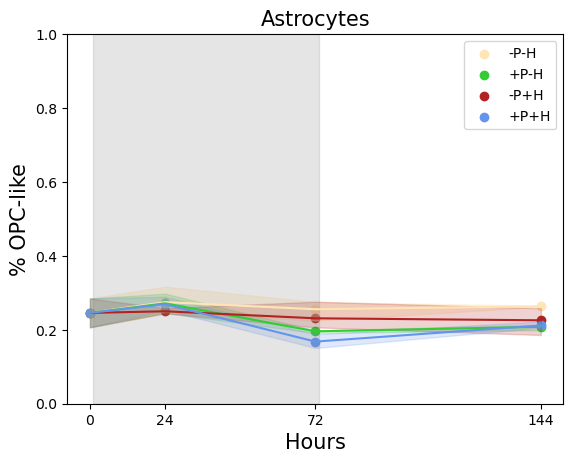

In [37]:
numb = merg.columns.astype(int)
plt.scatter(numb, merg.iloc[0],label=(merg.index[0]), color='moccasin')
plt.scatter(numb, merg.iloc[1],label=(merg.index[1]), color='limegreen')
plt.scatter(numb, merg.iloc[2],label=(merg.index[2]), color='firebrick')
plt.scatter(numb, merg.iloc[3],label=(merg.index[3]), color='cornflowerblue')
plt.plot(numb, merg.iloc[0], color='moccasin')
plt.fill_between(numb,np.min(merged1[0:3]),np.max(merged1[0:3]), color='moccasin', alpha=0.4)
plt.plot(numb, merg.iloc[1], color='limegreen')
plt.fill_between(numb,np.min(merged1[3:6]),np.max(merged1[3:6]), color='limegreen', alpha=0.2)
plt.plot(numb, merg.iloc[2], color='firebrick')
plt.fill_between(numb,np.min(merged1[6:9]),np.max(merged1[6:9]), color='firebrick', alpha=0.2)
plt.plot(numb, merg.iloc[3], color='cornflowerblue')
plt.fill_between(numb,np.min(merged1[9:12]),np.max(merged1[9:12]), color='cornflowerblue', alpha=0.2)
plt.ylim(0, 1)
plt.legend()
plt.xlabel('Hours', fontsize=15)
plt.ylabel('% OPC-like', fontsize=15)
plt.title('Astrocytes', fontsize=15)
plt.xticks(numb)
threshold1 = 0.2
threshold2 = 71
tr = numb +1.1
plt.fill_between(tr, 6, where= (tr < 140) & (tr > 0), color='grey', alpha=0.2)

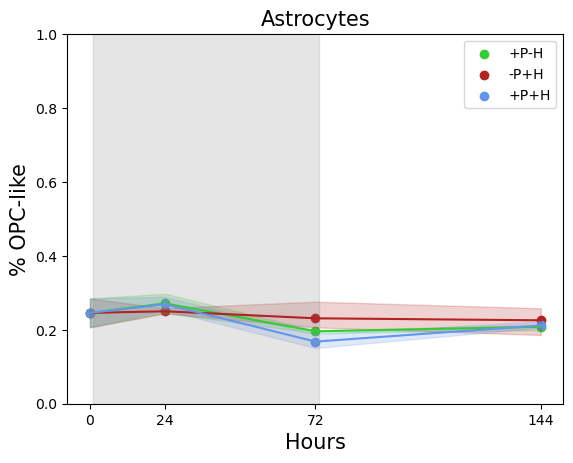

In [38]:
numb = merg.columns.astype(int)
#plt.scatter(numb, merg.iloc[0],label=(merg.index[0]), color='grey')
plt.scatter(numb, merg.iloc[1],label=(merg.index[1]), color='limegreen')
plt.scatter(numb, merg.iloc[2],label=(merg.index[2]), color='firebrick')
plt.scatter(numb, merg.iloc[3],label=(merg.index[3]), color='cornflowerblue')
#plt.plot(numb, merg.iloc[0], color='grey')
#plt.fill_between(numb,np.min(merged1[0:3]),np.max(merged1[0:3]), color='grey', alpha=0.2)
plt.plot(numb, merg.iloc[1], color='limegreen')
plt.fill_between(numb,np.min(merged1[3:6]),np.max(merged1[3:6]), color='limegreen', alpha=0.2)
plt.plot(numb, merg.iloc[2], color='firebrick')
plt.fill_between(numb,np.min(merged1[6:9]),np.max(merged1[6:9]), color='firebrick', alpha=0.2)
plt.plot(numb, merg.iloc[3], color='cornflowerblue')
plt.fill_between(numb,np.min(merged1[9:12]),np.max(merged1[9:12]), color='cornflowerblue', alpha=0.2)
plt.ylim(0, 1)
plt.legend()
plt.xlabel('Hours', fontsize=15)
plt.ylabel('% OPC-like', fontsize=15)
plt.title('Astrocytes', fontsize=15)
plt.xticks(numb)
threshold1 = 0.2
threshold2 = 71
tr = numb +1.1
plt.fill_between(tr, 6, where= (tr < 140) & (tr > 0), color='grey', alpha=0.2)
plt.show()

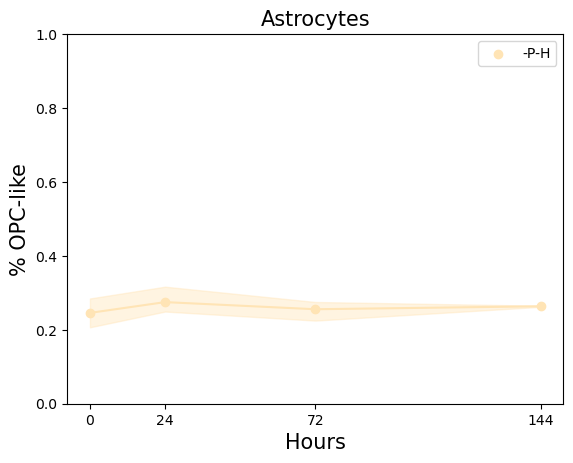

In [39]:
numb = merg.columns.astype(int)
plt.scatter(numb, merg.iloc[0],label=(merg.index[0]), color='moccasin')
plt.plot(numb, merg.iloc[0], color='moccasin')
plt.fill_between(numb,np.min(merged1[0:3]),np.max(merged1[0:3]), color='moccasin', alpha=0.4)
plt.ylim(0, 1)
plt.legend()
plt.xlabel('Hours', fontsize=15)
plt.ylabel('% OPC-like', fontsize=15)
plt.title('Astrocytes', fontsize=15)
plt.xticks(numb)
threshold1 = 0.2
threshold2 = 71
tr = numb +3
plt.show()

In [40]:
df = Astrocyte.to_df(layer=None)
df_all = df.sum(axis=1)
MES_df = df[AC]
df_mes = MES_df.sum(axis=1)
zero = Astrocyte[Astrocyte.obs["Time"] == "0h"]
zero_all = df_all[zero.obs.index]
zero_mes = df_mes[zero.obs.index]
one = Astrocyte[Astrocyte.obs["Time"] == "t1"]
one_all = df_all[one.obs.index]
one_mes = df_mes[one.obs.index]
three = Astrocyte[Astrocyte.obs["Time"] == "t3"]
three_all = df_all[three.obs.index]
three_mes = df_mes[three.obs.index]
six = Astrocyte[Astrocyte.obs["Time"] == "t6"]
six_all = df_all[six.obs.index]
six_mes = df_mes[six.obs.index]
MES_zero = zero_mes/zero_all
MES_one = one_mes/one_all
MES_three = three_mes/three_all
MES_six = six_mes/six_all
merged = pd.concat([MES_zero, MES_one, MES_three, MES_six], axis=1)
merged = merged.rename(columns={0: '0', 1: '24', 2:'72', 3: '144'})
rename = dict(Astrocyte.obs.Sample_Condition)
merged1 = merged.rename(index=rename)
merged1 = merged1.multiply(100)
rename = dict(Astrocyte.obs.Condition)
merg = merged.rename(index=rename)
merg = merg.mean(level=0)
merged1 = merged1.mean(level=0)
merged1 = merged1.reindex(["SVG_1_-P-H",'SVG_2_-P-H','SVG_3_-P-H',"SVG_1_+P-H","SVG_2_+P-H","SVG_3_+P-H","SVG_1_-P+H",'SVG_2_-P+H','SVG_3_-P+H',"SVG_1_+P+H",'SVG_2_+P+H','SVG_3_+P+H'])
merged1['0'] = dict(zip(merged1.index,np.concatenate(np.repeat([merged1[0:3]['0']], 4, axis=0))))
merged2 = merged1
merged1 = merged1.rename(index=dict(zip(merged1.index,["-P-H",'-P-H','-P-H',"+P-H","+P-H","+P-H","-P+H",'-P+H','-P+H',"+P+H",'+P+H','+P+H'])))
merg = merg.reindex(['-P-H', '+P-H','-P+H','+P+H'])
merg = merg.replace(np.nan, merg.iloc[0][0])
merg = merg.multiply(100)
merg

,0,24,72,144
-P-H,0.399004,0.483772,0.480066,0.504016
+P-H,0.399004,0.404805,0.378487,0.464915
-P+H,0.399004,0.453650,0.449778,0.427752
+P+H,0.399004,0.399325,0.437045,0.455830


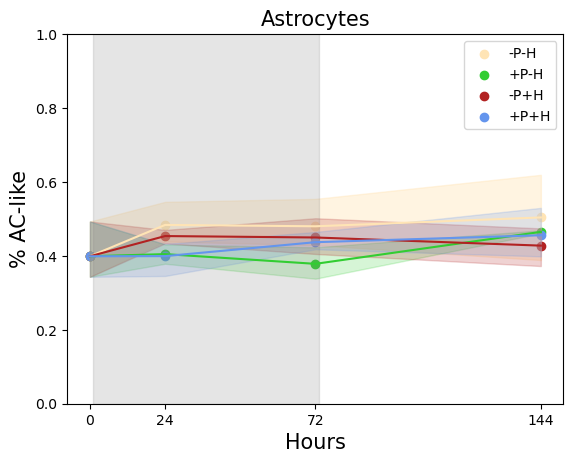

In [41]:
numb = merg.columns.astype(int)
plt.scatter(numb, merg.iloc[0],label=(merg.index[0]), color='moccasin')
plt.scatter(numb, merg.iloc[1],label=(merg.index[1]), color='limegreen')
plt.scatter(numb, merg.iloc[2],label=(merg.index[2]), color='firebrick')
plt.scatter(numb, merg.iloc[3],label=(merg.index[3]), color='cornflowerblue')
plt.plot(numb, merg.iloc[0], color='moccasin')
plt.fill_between(numb,np.min(merged1[0:3]),np.max(merged1[0:3]), color='moccasin', alpha=0.4)
plt.plot(numb, merg.iloc[1], color='limegreen')
plt.fill_between(numb,np.min(merged1[3:6]),np.max(merged1[3:6]), color='limegreen', alpha=0.2)
plt.plot(numb, merg.iloc[2], color='firebrick')
plt.fill_between(numb,np.min(merged1[6:9]),np.max(merged1[6:9]), color='firebrick', alpha=0.2)
plt.plot(numb, merg.iloc[3], color='cornflowerblue')
plt.fill_between(numb,np.min(merged1[9:12]),np.max(merged1[9:12]), color='cornflowerblue', alpha=0.2)
plt.ylim(0, 1)
plt.legend()
plt.xlabel('Hours', fontsize=15)
plt.ylabel('% AC-like', fontsize=15)
plt.title('Astrocytes', fontsize=15)
plt.xticks(numb)
threshold1 = 0.2
threshold2 = 71
tr = numb +1.1
plt.fill_between(tr, 6, where= (tr < 140) & (tr > 0), color='grey', alpha=0.2)

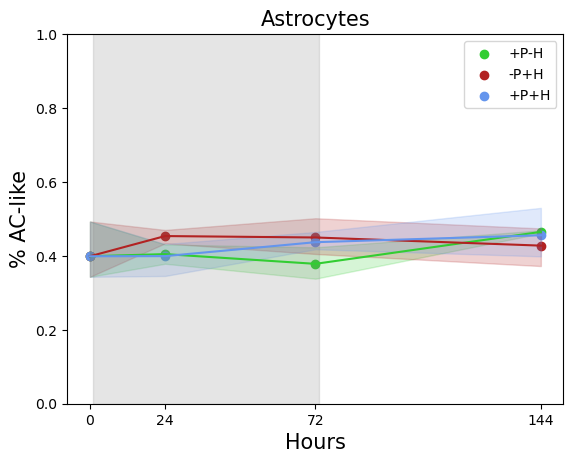

In [42]:
numb = merg.columns.astype(int)
#plt.scatter(numb, merg.iloc[0],label=(merg.index[0]), color='grey')
plt.scatter(numb, merg.iloc[1],label=(merg.index[1]), color='limegreen')
plt.scatter(numb, merg.iloc[2],label=(merg.index[2]), color='firebrick')
plt.scatter(numb, merg.iloc[3],label=(merg.index[3]), color='cornflowerblue')
#plt.plot(numb, merg.iloc[0], color='grey')
#plt.fill_between(numb,np.min(merged1[0:3]),np.max(merged1[0:3]), color='grey', alpha=0.2)
plt.plot(numb, merg.iloc[1], color='limegreen')
plt.fill_between(numb,np.min(merged1[3:6]),np.max(merged1[3:6]), color='limegreen', alpha=0.2)
plt.plot(numb, merg.iloc[2], color='firebrick')
plt.fill_between(numb,np.min(merged1[6:9]),np.max(merged1[6:9]), color='firebrick', alpha=0.2)
plt.plot(numb, merg.iloc[3], color='cornflowerblue')
plt.fill_between(numb,np.min(merged1[9:12]),np.max(merged1[9:12]), color='cornflowerblue', alpha=0.2)
plt.ylim(0, 1)
plt.legend()
plt.xlabel('Hours', fontsize=15)
plt.ylabel('% AC-like', fontsize=15)
plt.title('Astrocytes', fontsize=15)
plt.xticks(numb)
threshold1 = 0.2
threshold2 = 71
tr = numb +1.1
plt.fill_between(tr, 6, where= (tr < 140) & (tr > 0), color='grey', alpha=0.2)

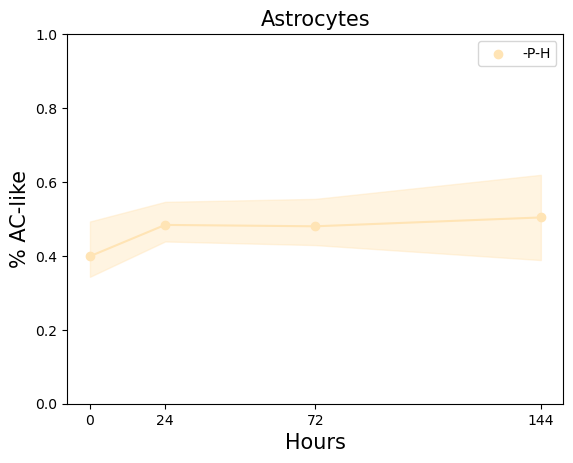

In [43]:
numb = merg.columns.astype(int)
plt.scatter(numb, merg.iloc[0],label=(merg.index[0]), color='moccasin')
plt.plot(numb, merg.iloc[0], color='moccasin')
plt.fill_between(numb,np.min(merged1[0:3]),np.max(merged1[0:3]), color='moccasin', alpha=0.4)
plt.ylim(0, 1)
plt.legend()
plt.xlabel('Hours', fontsize=15)
plt.ylabel('% AC-like', fontsize=15)
plt.title('Astrocytes', fontsize=15)
plt.xticks(numb)
threshold1 = 0.2
threshold2 = 71
tr = numb +3
#plt.fill_between(tr, 6, where= (tr < 140) & (tr > 0), color='grey', alpha=0.2)

In [44]:
df = Astrocyte.to_df(layer=None)
df_all = df.sum(axis=1)
MES_df = df[NPC]
df_mes = MES_df.sum(axis=1)
zero = Astrocyte[Astrocyte.obs["Time"] == "0h"]
zero_all = df_all[zero.obs.index]
zero_mes = df_mes[zero.obs.index]
one = Astrocyte[Astrocyte.obs["Time"] == "t1"]
one_all = df_all[one.obs.index]
one_mes = df_mes[one.obs.index]
three = Astrocyte[Astrocyte.obs["Time"] == "t3"]
three_all = df_all[three.obs.index]
three_mes = df_mes[three.obs.index]
six = Astrocyte[Astrocyte.obs["Time"] == "t6"]
six_all = df_all[six.obs.index]
six_mes = df_mes[six.obs.index]
MES_zero = zero_mes/zero_all
MES_one = one_mes/one_all
MES_three = three_mes/three_all
MES_six = six_mes/six_all
merged = pd.concat([MES_zero, MES_one, MES_three, MES_six], axis=1)
merged = merged.rename(columns={0: '0', 1: '24', 2:'72', 3: '144'})
rename = dict(Astrocyte.obs.Sample_Condition)
merged1 = merged.rename(index=rename)
merged1 = merged1.multiply(100)
rename = dict(Astrocyte.obs.Condition)
merg = merged.rename(index=rename)
merg = merg.mean(level=0)
merged1 = merged1.mean(level=0)
merged1 = merged1.reindex(["SVG_1_-P-H",'SVG_2_-P-H','SVG_3_-P-H',"SVG_1_+P-H","SVG_2_+P-H","SVG_3_+P-H","SVG_1_-P+H",'SVG_2_-P+H','SVG_3_-P+H',"SVG_1_+P+H",'SVG_2_+P+H','SVG_3_+P+H'])
merged1['0'] = dict(zip(merged1.index,np.concatenate(np.repeat([merged1[0:3]['0']], 4, axis=0))))
merged2 = merged1
merged1 = merged1.rename(index=dict(zip(merged1.index,["-P-H",'-P-H','-P-H',"+P-H","+P-H","+P-H","-P+H",'-P+H','-P+H',"+P+H",'+P+H','+P+H'])))
merg = merg.reindex(['-P-H', '+P-H','-P+H','+P+H'])
merg = merg.replace(np.nan, merg.iloc[0][0])
merg = merg.multiply(100)
merg

,0,24,72,144
-P-H,0.5431,0.578972,0.534395,0.568420
+P-H,0.5431,0.560320,0.491397,0.488966
-P+H,0.5431,0.556650,0.529833,0.556488
+P+H,0.5431,0.585382,0.489843,0.519442


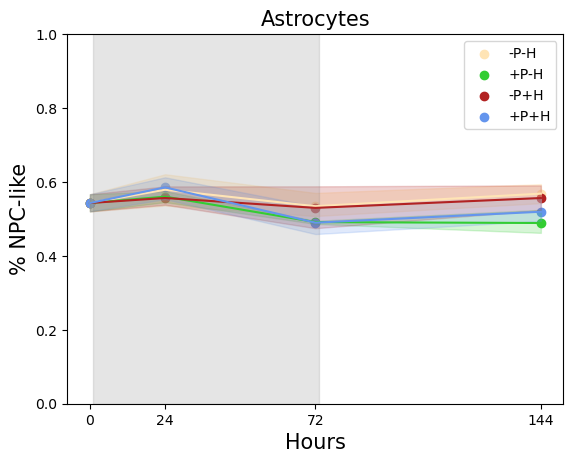

In [45]:
numb = merg.columns.astype(int)
plt.scatter(numb, merg.iloc[0],label=(merg.index[0]), color='moccasin')
plt.scatter(numb, merg.iloc[1],label=(merg.index[1]), color='limegreen')
plt.scatter(numb, merg.iloc[2],label=(merg.index[2]), color='firebrick')
plt.scatter(numb, merg.iloc[3],label=(merg.index[3]), color='cornflowerblue')
plt.plot(numb, merg.iloc[0], color='moccasin')
plt.fill_between(numb,np.min(merged1[0:3]),np.max(merged1[0:3]), color='moccasin', alpha=0.4)
plt.plot(numb, merg.iloc[1], color='limegreen')
plt.fill_between(numb,np.min(merged1[3:6]),np.max(merged1[3:6]), color='limegreen', alpha=0.2)
plt.plot(numb, merg.iloc[2], color='firebrick')
plt.fill_between(numb,np.min(merged1[6:9]),np.max(merged1[6:9]), color='firebrick', alpha=0.2)
plt.plot(numb, merg.iloc[3], color='cornflowerblue')
plt.fill_between(numb,np.min(merged1[9:12]),np.max(merged1[9:12]), color='cornflowerblue', alpha=0.2)
plt.ylim(0, 1)
plt.legend()
plt.xlabel('Hours', fontsize=15)
plt.ylabel('% NPC-like', fontsize=15)
plt.title('Astrocytes', fontsize=15)
plt.xticks(numb)
threshold1 = 0.2
threshold2 = 71
tr = numb +1.1
plt.fill_between(tr, 6, where= (tr < 140) & (tr > 0), color='grey', alpha=0.2)

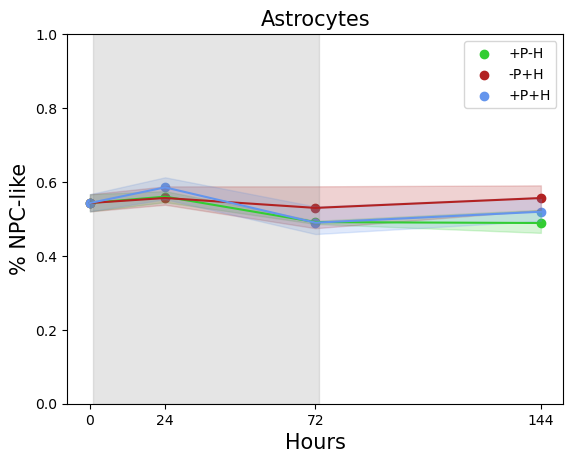

In [46]:
numb = merg.columns.astype(int)
#plt.scatter(numb, merg.iloc[0],label=(merg.index[0]), color='grey')
plt.scatter(numb, merg.iloc[1],label=(merg.index[1]), color='limegreen')
plt.scatter(numb, merg.iloc[2],label=(merg.index[2]), color='firebrick')
plt.scatter(numb, merg.iloc[3],label=(merg.index[3]), color='cornflowerblue')
#plt.plot(numb, merg.iloc[0], color='grey')
#plt.fill_between(numb,np.min(merged1[0:3]),np.max(merged1[0:3]), color='grey', alpha=0.2)
plt.plot(numb, merg.iloc[1], color='limegreen')
plt.fill_between(numb,np.min(merged1[3:6]),np.max(merged1[3:6]), color='limegreen', alpha=0.2)
plt.plot(numb, merg.iloc[2], color='firebrick')
plt.fill_between(numb,np.min(merged1[6:9]),np.max(merged1[6:9]), color='firebrick', alpha=0.2)
plt.plot(numb, merg.iloc[3], color='cornflowerblue')
plt.fill_between(numb,np.min(merged1[9:12]),np.max(merged1[9:12]), color='cornflowerblue', alpha=0.2)
plt.ylim(0, 1)
plt.legend()
plt.xlabel('Hours', fontsize=15)
plt.ylabel('% NPC-like', fontsize=15)
plt.title('Astrocytes', fontsize=15)
plt.xticks(numb)
threshold1 = 0.2
threshold2 = 71
tr = numb +1.1
plt.fill_between(tr, 6, where= (tr < 140) & (tr > 0), color='grey', alpha=0.2)

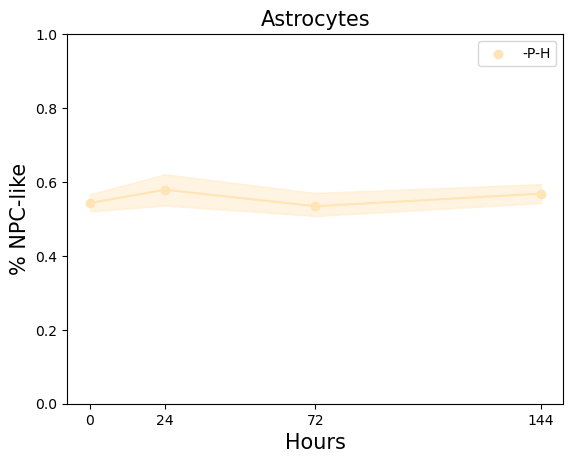

In [47]:
numb = merg.columns.astype(int)
plt.scatter(numb, merg.iloc[0],label=(merg.index[0]), color='moccasin')
plt.plot(numb, merg.iloc[0], color='moccasin')
plt.fill_between(numb,np.min(merged1[0:3]),np.max(merged1[0:3]), color='moccasin', alpha=0.4)
plt.ylim(0, 1)
plt.legend()
plt.xlabel('Hours', fontsize=15)
plt.ylabel('% NPC-like', fontsize=15)
plt.title('Astrocytes', fontsize=15)
plt.xticks(numb)
threshold1 = 0.2
threshold2 = 71
tr = numb +3